In [1]:
import numpy as np
import pandas as pd
import h5py
import os, sys
import torch
from transformers import AutoTokenizer
os.chdir('../../../results/pseudo_gene/')
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [2]:
junctions = ["start_sites", "stop_sites", "donor", "acceptor"]
cad2_suffixes = {
    "start_sites": "filtered_ATG",
    "stop_sites": "filtered_TAG", 
    "donor": "filtered_GT",
    "acceptor": "filtered_AG"
}

evo2_suffixes = {
    "start_sites": "evo2_7b_ntokens_3",
    "stop_sites": "evo2_7b_ntokens_3",
    "donor": "filtered_evo2_7b_ntokens_2",
    "acceptor": "filtered_evo2_7b_ntokens_2"
}

taxa = "B73_"
fnames_cad2 = [f"splice_junctions/{taxa}{type}_{cad2_suffixes[type]}.h5" for type in junctions]
fnames_evo2 = [f"outputs/{taxa}{type}_{evo2_suffixes[type]}.npz" for type in junctions]
fnames_label = [f"splice_junctions/{taxa}{type}_filtered_labels.tsv" for type in junctions]

In [3]:
def process_array_by_groups(arr, true_token_ids, group_size=3):
    tokenProb = []
    for row, token_id in zip(arr, true_token_ids):
        curToken = tokenizer.convert_ids_to_tokens(int(token_id))
        curProb = row[nucleotides.index(curToken)]
        tokenProb.append(curProb)
    
    avg_tokenProb = [np.mean(tokenProb[i:i+group_size]) for i in range(0, len(tokenProb), group_size)]
    return avg_tokenProb

def create_binary_labels(label):
    return 1 if label == "Core Gene" else 0

def chunks(lst, n):
    return [''.join(lst[i:i+n]).upper() for i in range(0, len(lst), n)]
    
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [4]:
labels_dict = {}
nucleotides = list('acgt')
for idx, junction in enumerate(junctions):
    label = pd.read_csv(fnames_label[idx], sep='\t')
    
    # load plantcad2 logits
    with h5py.File(fnames_cad2[idx], 'a') as hf:
        plantcad2_logits = torch.tensor(hf['predicted_logits'][:])
        true_ids = torch.tensor(hf['true_token_ids'][:])

    plantcad2_logits = plantcad2_logits[:, [tokenizer.get_vocab()[nc] for nc in nucleotides]] # only retain atcg
    plantcad2_logits = torch.tensor(plantcad2_logits)
    plantcad2_probs = torch.nn.functional.softmax(plantcad2_logits, dim=1).numpy()

    # load evo2 logits
    loaded = np.load(fnames_evo2[idx])
    evo_probs = loaded['logits']
    evo_probs_reshaped = evo_probs.reshape(-1, 4)
    
    if junction in ['start_sites', 'stop_sites']:
        plantcad2_scores = process_array_by_groups(plantcad2_probs, true_ids, group_size=3)
        evo2_scores = process_array_by_groups(evo_probs_reshaped, true_ids, group_size=3)
    else:
        plantcad2_scores = process_array_by_groups(plantcad2_probs, true_ids, group_size=2)
        evo2_scores = process_array_by_groups(evo_probs_reshaped, true_ids, group_size=2)

    label['predicted_plantcad2'] = plantcad2_scores
    label['predicted_evo2'] = evo2_scores
    labels_dict[junction] = label

/tmp/ipykernel_3394355/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_3394355/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_3394355/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plantcad2_logits = torch.tensor(plantcad2_logits)
/tmp/ipykernel_3394355/1620971698.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().

In [5]:
labels_dict['start_sites'].head()

,Transcript_ID,Label,predicted_plantcad2,predicted_evo2
0,Zm00001eb000010_T001,Near-Core Gene,0.765859,0.192725
1,Zm00001eb000020_T001,Core Gene,0.326974,0.289361
2,Zm00001eb000050_T001,Dispensable Gene,0.781113,0.198969
3,Zm00001eb000060_T001,Dispensable Gene,0.316062,0.275791
4,Zm00001eb000070_T001,Dispensable Gene,0.375905,0.338734


In [6]:
labels_dict['donor'].head()

,Transcript_ID,Label,predicted_plantcad2,predicted_evo2
0,Zm00001eb000010_T001,Near-Core Gene,0.961297,0.277287
1,Zm00001eb000010_T001,Near-Core Gene,0.997193,0.904939
2,Zm00001eb000010_T001,Near-Core Gene,0.948152,0.828261
3,Zm00001eb000010_T001,Near-Core Gene,0.981640,0.960409
4,Zm00001eb000010_T001,Near-Core Gene,0.999338,0.990514


In [7]:
donor_collapse = labels_dict['donor'].groupby('Transcript_ID')[['predicted_plantcad2', 'predicted_evo2']].mean()
acceptor_collapse  = labels_dict['acceptor'].groupby('Transcript_ID')[['predicted_plantcad2', 'predicted_evo2']].mean()

In [8]:
donor_collapse.shape, acceptor_collapse.shape, labels_dict['start_sites'].shape, labels_dict['stop_sites'].shape

((30112, 2), (30112, 2), (39035, 4), (39035, 4))

In [9]:
donor_collapse = donor_collapse.rename(columns={
    'predicted_plantcad2': 'predicted_plantcad2_donor',
    'predicted_evo2': 'predicted_evo2_donor'
})

acceptor_collapse = acceptor_collapse.rename(columns={
    'predicted_plantcad2': 'predicted_plantcad2_acceptor',
    'predicted_evo2': 'predicted_evo2_acceptor'
})

# Then merge
merged_df = labels_dict['start_sites'].merge(
    labels_dict['stop_sites'], 
    on='Transcript_ID', 
    how='left'
).merge(
    donor_collapse, 
    on='Transcript_ID', 
    how='left'
).merge(
    acceptor_collapse, 
    on='Transcript_ID', 
    how='left'
)

In [10]:
merged_df.head()

,Transcript_ID,Label_x,predicted_plantcad2_x,predicted_evo2_x,Label_y,predicted_plantcad2_y,predicted_evo2_y,predicted_plantcad2_donor,predicted_evo2_donor,predicted_plantcad2_acceptor,predicted_evo2_acceptor
0,Zm00001eb000010_T001,Near-Core Gene,0.765859,0.192725,Near-Core Gene,0.362822,0.373660,0.831912,0.703106,0.838132,0.291474
1,Zm00001eb000020_T001,Core Gene,0.326974,0.289361,Core Gene,0.289071,0.297226,0.712735,0.346828,0.678519,0.308027
2,Zm00001eb000050_T001,Dispensable Gene,0.781113,0.198969,Dispensable Gene,0.260636,0.239869,0.696491,0.227106,0.853467,0.294669
3,Zm00001eb000060_T001,Dispensable Gene,0.316062,0.275791,Dispensable Gene,0.242656,0.191700,0.814965,0.271828,0.256761,0.185997
4,Zm00001eb000070_T001,Dispensable Gene,0.375905,0.338734,Dispensable Gene,0.559174,0.399406,0.675951,0.497114,0.546832,0.301465


In [11]:
plantcad2_scores = merged_df[['predicted_plantcad2_x', 'predicted_plantcad2_y', 'predicted_plantcad2_donor', 'predicted_plantcad2_acceptor']].mean(axis=1)
evo2_scores = merged_df[['predicted_evo2_x', 'predicted_evo2_y', 'predicted_evo2_donor', 'predicted_evo2_acceptor']].mean(axis=1)

In [12]:
merged_df['plantcad2_scores'] = plantcad2_scores
merged_df['evo2_scores'] = evo2_scores

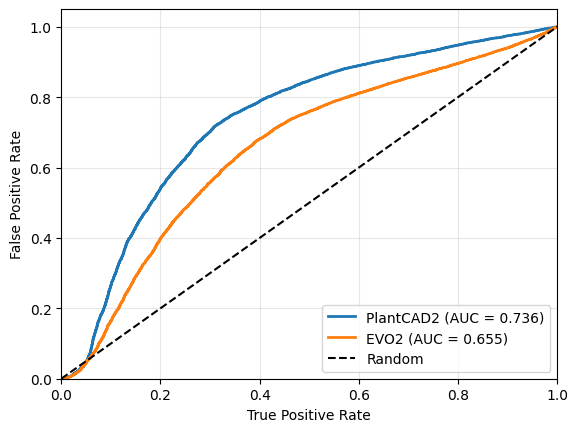

In [18]:
subsets = merged_df[merged_df['Label_x'] != 'Near-Core Gene'].copy()
subsets['binary_label'] = subsets['Label_x'].apply(create_binary_labels)
y_true = subsets['binary_label'].values
y_scores_cad2 = subsets['plantcad2_scores'].values
y_scores_evo2 = subsets['evo2_scores'].values

fpr_cad2, tpr_cad2, _ = roc_curve(y_true, y_scores_cad2)
fpr_evo2, tpr_evo2, _ = roc_curve(y_true, y_scores_evo2)

roc_auc_cad2 = auc(fpr_cad2, tpr_cad2)
roc_auc_evo2 = auc(fpr_evo2, tpr_evo2)

plt.plot(fpr_cad2, tpr_cad2, 
       label=f'PlantCAD2 (AUC = {roc_auc_cad2:.3f})',
       color='C0', linewidth = 2)
plt.plot(fpr_evo2, tpr_evo2, 
       label=f'EVO2 (AUC = {roc_auc_evo2:.3f})',
       color='C1', linewidth = 2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.savefig('../../pipelines/pseudo_gene/Core_noncore_gene_classification.pdf', format='pdf',bbox_inches='tight')
plt.show()